# **Terceiro trabalho de aprendizado de maquina** - Pinguins - Parte 2

## **1)** Importação de bibliotecas e classes

In [63]:
# Bibliotecas de cálculo, manipulação de dados e geração de gráficos
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [64]:
# Bibliotecas específicas de Machine Learning
from sklearn.preprocessing import StandardScaler    # Padronização de atributos
from sklearn.cluster import AgglomerativeClustering # Agrupamento hierárquico
from sklearn.cluster import DBSCAN                  # Agrupamento baseado em densidade

## **2)** Leitura de dados e exploração inicial

In [65]:
# Leitura do arquivo de dados e exibição do DataFrame
# ATENÇÃO: "monte" o disco e ajuste o caminho do arquivo de dados!
caminho_arquivo = "/content/drive/MyDrive/Colab Notebooks/Ciência de Dados e Inteligência Artificial/Aprendizado de Maquina/Datasets/penguins_size.csv"

df = pd.read_csv(caminho_arquivo)
display(df)

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,FEMALE
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,MALE
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,FEMALE


### **2.1)** Gráficos

In [66]:
# Investigar valores ausentes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   culmen_length_mm   342 non-null    float64
 3   culmen_depth_mm    342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                334 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [67]:
columns_to_check = ['culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm', 'body_mass_g']
df.dropna(subset=columns_to_check, inplace=True)

In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 342 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            342 non-null    object 
 1   island             342 non-null    object 
 2   culmen_length_mm   342 non-null    float64
 3   culmen_depth_mm    342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                334 non-null    object 
dtypes: float64(4), object(3)
memory usage: 21.4+ KB


In [69]:
df.isnull().sum()

,0
species,0
island,0
culmen_length_mm,0
culmen_depth_mm,0
flipper_length_mm,0
body_mass_g,0
sex,8


In [70]:
# Contagem dos sexos do pinguins
df['sex'].value_counts()

,count
sex,
MALE,168
FEMALE,165
.,1


In [71]:
# Resumo estatistico
df.describe()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


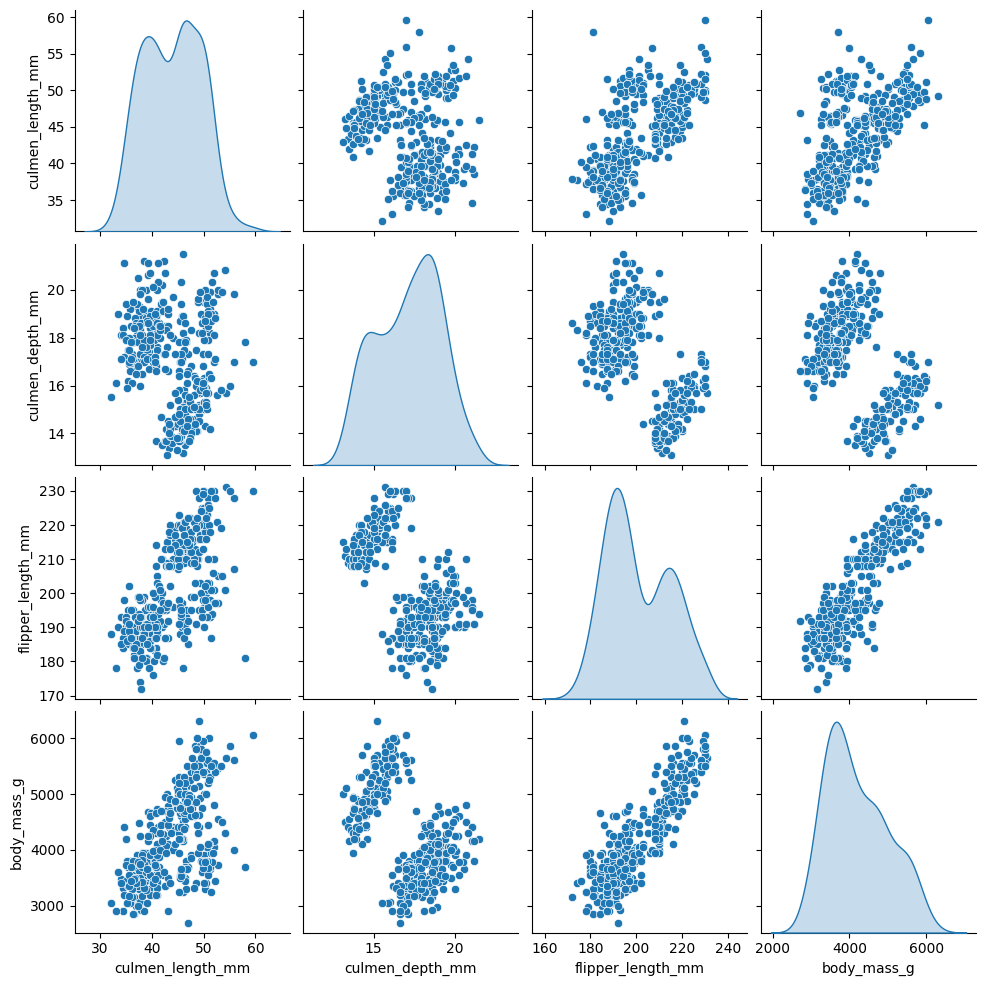

In [72]:
# Matriz de diagramas de dispersão (ignorando a rotulação)
sns.pairplot(data = df.drop(columns = ['species', 'island', 'sex']), diag_kind = 'kde')
plt.show()

## **3)** Seleção e pré-processamento de variáveis

In [73]:
# Recordando os nomes das colunas do DataFrame
df.columns

Index(['species', 'island', 'culmen_length_mm', 'culmen_depth_mm',
       'flipper_length_mm', 'body_mass_g', 'sex'],
      dtype='object')

In [74]:
# Atributos: características físicas
X = df.drop(columns = ['species', 'island', 'sex'])

In [75]:
# Pré-processamento ÚNICO: padronização dos atributos do CONJUNTO COMPLETO DE DADOS
escalonador = StandardScaler()      # Cria instância de objeto "escalonador"
escalonador.fit(X)                  # Calcula a média e a variância dos atributos
X_Padr = escalonador.transform(X)   # Padroniza os dados

## **4)** Agrupamento via algoritmo *DBSCAN*

### **4.1)** Treinamento do *clusterizador*

In [76]:
# PRIMEIRA TENTATIVA:
# Uso do algoritmo DBSCAN com os valores padrão
# dos hiperparâmetros: eps = 0.5; min_samples = 5
# Criação de instância e treinamento do clusterizador
clt_DB = DBSCAN(eps = 0.5, min_samples = 5)
clt_DB.fit(X_Padr)

DBSCAN()

### **4.2**) Resultados do agrupamento

In [77]:
# Centros de clusters = pontos centrais
print("Foram identificados",len(clt_DB.core_sample_indices_),"pontos de centro.")
print("Índices:")
print(clt_DB.core_sample_indices_)

Foram identificados 203 pontos de centro.
Índices:
[  0   1   3   4   5   7   9  10  14  15  20  21  23  24  25  26  31  32
  33  35  40  43  44  47  49  50  51  52  54  55  56  58  59  61  62  63
  64  67  70  73  74  75  76  78  79  81  83  85  86  87  88  91  93  95
  96  98  99 104 106 111 112 113 114 117 119 124 125 126 127 129 131 133
 134 135 137 138 139 140 142 143 144 145 146 147 148 149 150 151 152 153
 158 160 161 165 166 174 178 179 184 185 192 193 195 202 203 204 209 211
 213 216 218 219 220 222 224 225 226 227 228 230 231 233 234 235 237 238
 240 241 242 244 246 247 248 249 250 251 253 254 255 257 260 261 262 263
 264 265 266 268 269 271 273 274 275 276 277 278 279 280 281 283 284 285
 286 288 289 290 291 292 293 294 295 297 299 300 301 302 303 305 307 308
 309 310 311 312 313 314 315 316 318 319 321 323 327 329 330 332 333 335
 336 337 338 339 340]


In [78]:
print("Rótulos dos elementos:")
print(clt_DB.labels_)

Rótulos dos elementos:
[ 0  0  0  0  0  0 -1  0 -1  0  0  0  0 -1  0  0 -1  0 -1 -1  0  0  0  0
  0  0  0 -1  0 -1 -1  0  0  0 -1  0  0  0  0  0  0 -1  0  0  0  0 -1  0
 -1  0  0  0  0 -1  0  0  0  0  0  0 -1  0  0  0  0  0  0  0  0  0  0  0
 -1  0  0  0  0  0  0  0 -1  0 -1  0 -1  0  0  0  0 -1 -1  0  0  0 -1  0
  0 -1  0  0 -1 -1  0 -1  0 -1  0  0 -1 -1 -1  0  0  0  0  0 -1  0  0  0
  0 -1  0  0  0  0  0  0 -1  0 -1  0 -1  0  0  0  0  0  0  0  0 -1  0  0
  0  0  0  0  0  0  0  1  2  2 -1  2  1 -1  2 -1  2  1  2  1  2  1  2 -1
 -1  1 -1 -1  1 -1  2  1  2  2  2  1 -1  0 -1  0  2  2 -1  1 -1 -1 -1 -1
  1  2  1  2  2 -1 -1 -1  2 -1  2  1  2  0  2 -1  2  2 -1  2  1  1 -1 -1
  2  2  2  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3 -1  3  3  3
  3  3  3  3  3  3  3  3  3  3  3  3 -1  3  3  3 -1  3 -1  3  3  3  3  3
  3  3  3 -1  3  3  3  3  3  3  3  3  3  3  3  3  3  3 -1  3  3  3  3  3
  3  3  3  3  3  3  3  3  3  3 -1  3  3  3  3  3  3  3 -1  3  3  3  3  3
  3  3  3  3  3  3  3  3 -1 

In [79]:
print("Rótulos atribuídos:",np.unique(clt_DB.labels_))
print(sum(clt_DB.labels_ < 0),"elementos foram identificados como ruído.")

Rótulos atribuídos: [-1  0  1  2  3]
69 elementos foram identificados como ruído.


In [80]:
print("Total de elementos por cluster:")
print(pd.Series(clt_DB.labels_).value_counts())

Total de elementos por cluster:
 0    118
 3    113
-1     69
 2     27
 1     15
Name: count, dtype: int64


### **4.3)** Gráficos

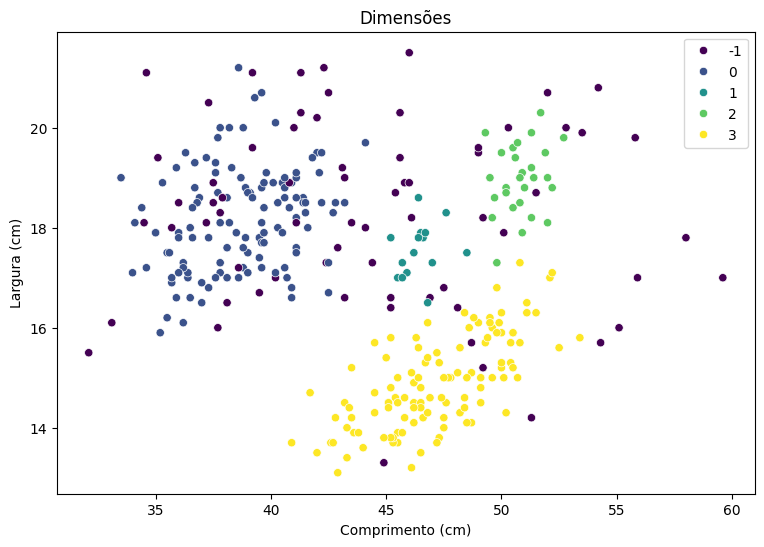

In [81]:
# Diagrama de dispersão entre comprimento e largura da pétala
# Ajustes da figura
# Tamanho do gráfico (polegadas): largura = 9, altura = 6
plt.figure(figsize = (9,6))

# Título e rótulos dos eixos
plt.title("Dimensões")
plt.xlabel("Comprimento (cm)")
plt.ylabel("Largura (cm)")

sns.scatterplot(data = df, x = 'culmen_length_mm', y = 'culmen_depth_mm',
                hue = clt_DB.labels_, palette = 'viridis')
plt.show()

## **5)** Dimensionamento dos hiperparâmetros

### **5.1)** Análise visual do raio de alcance

In [82]:
# Número mínimo de vizinhos (min_samples) = 2*total de atributos
k = 2*X_Padr.shape[1]
k

8

In [83]:
# Raio de alcance (eps)
# 1) Determinação da matriz de k menores distâncias
from sklearn.neighbors import NearestNeighbors

mdi = NearestNeighbors(n_neighbors = k+1).fit(X_Padr)   # Cria e treina instância
dist, ind = mdi.kneighbors(X_Padr)   # Calcula distâncias e índices
dist    # Exibe a matriz de distâncias. Neste caso, shape = (150,9)

array([[0.        , 0.31158625, 0.32574369, ..., 0.44726081, 0.48376025,
        0.51319637],
       [0.        , 0.3293166 , 0.40476285, ..., 0.4698828 , 0.47227091,
        0.4773091 ],
       [0.        , 0.24381594, 0.44607676, ..., 0.55270967, 0.57140363,
        0.57657283],
       ...,
       [0.        , 0.27018805, 0.30696652, ..., 0.39335853, 0.42791665,
        0.44327672],
       [0.        , 0.33413233, 0.36264308, ..., 0.47997993, 0.51596272,
        0.56428633],
       [0.        , 0.32862111, 0.46936517, ..., 0.66974115, 0.67097336,
        0.68039858]])

In [84]:
ind   # Exibe a matriz de índices

array([[  0, 144,  20, ...,  32,   5,  22],
       [  1,  55,  49, ..., 140,  22,   5],
       [  2, 111, 125, ..., 118,  71,  26],
       ...,
       [339, 263, 260, ..., 222, 234, 288],
       [340, 244, 240, ..., 313, 225, 268],
       [341, 230, 258, ..., 248, 234, 328]])

In [85]:
# 2) Ordenação das distâncias dos k-ésimos vizinhos mais próximos
dist = np.sort(dist,axis = 0)   # axis = 0: ordenação em cada COLUNA
k_dist = dist[:,k]    # Seleciona todas as linhas, última coluna

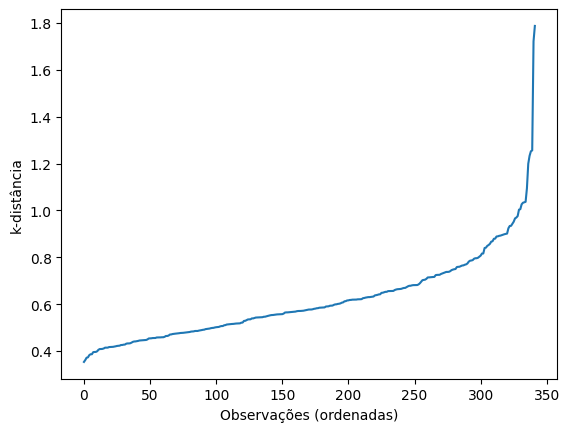

In [86]:
# 3) Traça a curva (gráfico de linha) da função k-distâncias (ordenadas)
plt.plot(k_dist)
plt.xlabel("Observações (ordenadas)")
plt.ylabel("k-distância")
plt.show()

In [87]:
# Definição do raio de alcance "ideal" (análise gráfica)
raio = 1

In [88]:
# SEGUNDA TENTATIVA:
# Uso do algoritmo DBSCAN com hiperparâmetros dimensionados
# Criação de instância e treinamento do clusterizador
clt_DB = DBSCAN(eps = raio, min_samples = k)
clt_DB.fit(X_Padr)

DBSCAN(eps=1, min_samples=8)

In [89]:
# Exibição dos resultados do NOVO agrupamento
# Total de cluters e outliers
print("Rótulos atribuídos:",np.unique(clt_DB.labels_))
print(sum(clt_DB.labels_ < 0),"elementos foram identificados como ruído.")

print("")   # "Imprime" uma linha em branco
print("Total de elementos por cluster:")
print(pd.Series(clt_DB.labels_).value_counts())

Rótulos atribuídos: [-1  0  1]
1 elementos foram identificados como ruído.

Total de elementos por cluster:
 0    218
 1    123
-1      1
Name: count, dtype: int64


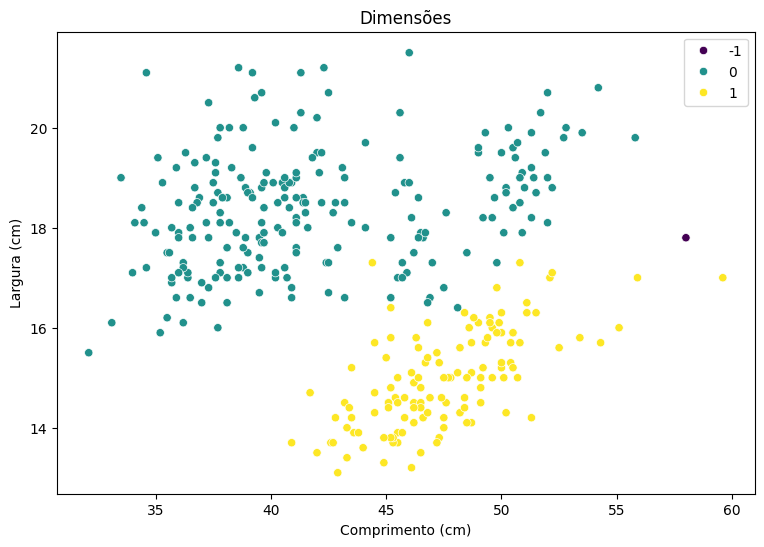

In [96]:
# Representações gráficas da SEGUNDA TENTATIVA de agrupamento via DBSCAN
# Diagrama de dispersão entre comprimento e largura
# Ajustes da figura
# Tamanho do gráfico (polegadas): largura = 9, altura = 6
plt.figure(figsize = (9,6))

# Título e rótulos dos eixos
plt.title("Dimensões")
plt.xlabel("Comprimento (cm)")
plt.ylabel("Largura (cm)")

sns.scatterplot(data = df, x = 'culmen_length_mm', y = 'culmen_depth_mm',
                hue = clt_DB.labels_, palette = 'viridis')
plt.show()

### **5.2)** Ajuste automatizado do raio de alcance

In [91]:
# Abordagem matemática: cotovelo = ponto de curvatura máxima!
# Instalação de biblioteca para detecção do joelho/cotovelo
# Descrição do projeto: https://pypi.org/project/kneed/
!pip install kneed

Cotovelo em x = 338
k-distância associada = 1.252593614424266



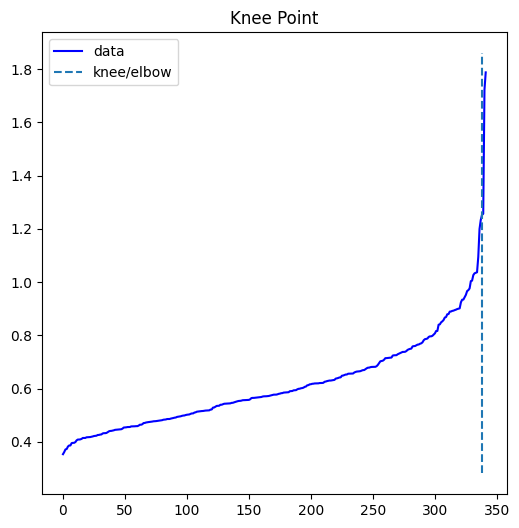

In [92]:
# Importação e aplicação da função de detecção
from kneed import KneeLocator

cotovelo = KneeLocator(x = range(0,len(k_dist)), y = k_dist,
                       S = 1.0, curve = "concave",
                       direction = "increasing",
                       online = True)

print("Cotovelo em x =",cotovelo.elbow)             # Opção: objeto.knee
print("k-distância associada =",cotovelo.elbow_y)   # Opção: objeto.knee_y
print("")   # "Imprime" uma linha em branco

# Exibição gráfica do resultado
cotovelo.plot_knee()
plt.show()

## **6)** Agrupamento final

In [93]:
# Treinamento FINAL do algoritmo DBSCAN com hiperparâmetros dimensionados
# Criação de instância e treinamento do clusterizador
clt_DB = DBSCAN(eps = cotovelo.elbow_y, min_samples = k)
clt_DB.fit(X_Padr)

DBSCAN(eps=np.float64(1.252593614424266), min_samples=8)

In [94]:
# Exibição dos resultados do NOVO agrupamento
# Total de cluters e outliers
print("Rótulos atribuídos:",np.unique(clt_DB.labels_))
print(sum(clt_DB.labels_ < 0),"elementos foram identificados como ruído.")

print("")   # "Imprime" uma linha em branco
print("Total de elementos por cluster:")
print(pd.Series(clt_DB.labels_).value_counts())

Rótulos atribuídos: [-1  0  1]
1 elementos foram identificados como ruído.

Total de elementos por cluster:
 0    218
 1    123
-1      1
Name: count, dtype: int64


#### **6.1)** Gráficos finais

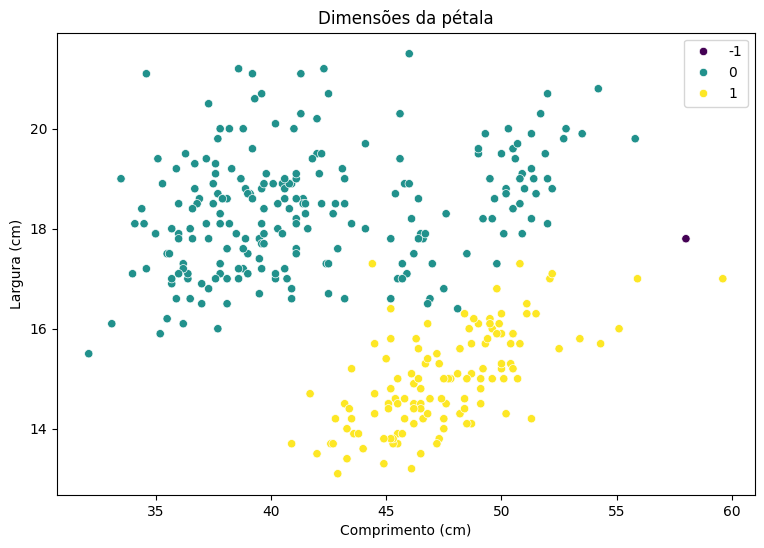

In [95]:
# Diagrama de dispersão entre comprimento e largura da pétala
# Ajustes da figura
# Tamanho do gráfico (polegadas): largura = 9, altura = 6
plt.figure(figsize = (9,6))

# Título e rótulos dos eixos
plt.title("Dimensões da pétala")
plt.xlabel("Comprimento (cm)")
plt.ylabel("Largura (cm)")

sns.scatterplot(data = df, x = 'culmen_length_mm', y = 'culmen_depth_mm',
                hue = clt_DB.labels_, palette = 'viridis')
plt.show()

## **6)** Agrupamento via algoritmo *Agrupamento Hierarquico*

### **6.1)** Treinamento do *clusterizador*

In [97]:
# PRIMEIRA TENTATIVA:
# Criação de instância e treinamento do HAC,
# formando 2 clusters (padrão)
clt_AC = AgglomerativeClustering(n_clusters = 2)
clt_AC.fit(X_Padr)

AgglomerativeClustering()

### **6.2)** Resultados do agrupamento

In [98]:
print("Rótulos dos elementos:")
print(clt_AC.labels_)

Rótulos dos elementos:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1]


In [99]:
print("Rótulos atribuídos:",np.unique(clt_AC.labels_))

Rótulos atribuídos: [0 1]


In [100]:
print("Total de clusters gerados:",clt_AC.n_clusters_)

Total de clusters gerados: 2


In [101]:
print("Total de elementos por cluster:")
print(pd.Series(clt_AC.labels_).value_counts())

Total de elementos por cluster:
0    219
1    123
Name: count, dtype: int64


### **6.3)** Gráficos

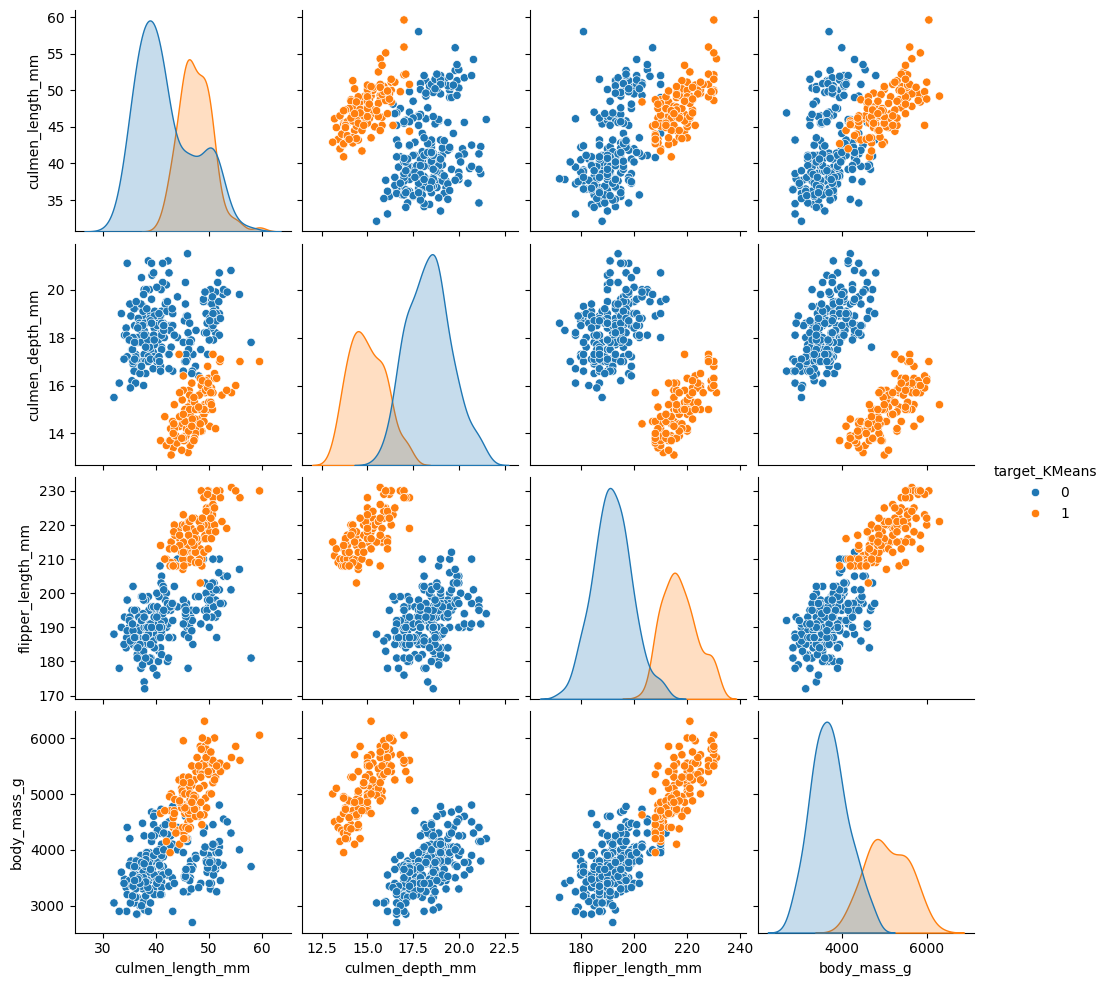

In [103]:
# Matriz de diagramas de dispersão, com separação de cor de acordo
# com a rotulação definida pelo clusterizador

# Atribuição dos rótulos de cluster/cor ao DataFrame
df['target_KMeans'] = clt_AC.labels_

sns.pairplot(data = df.drop(columns = ['species', 'island', 'sex']),
             diag_kind = 'kde', hue = 'target_KMeans')
plt.show()

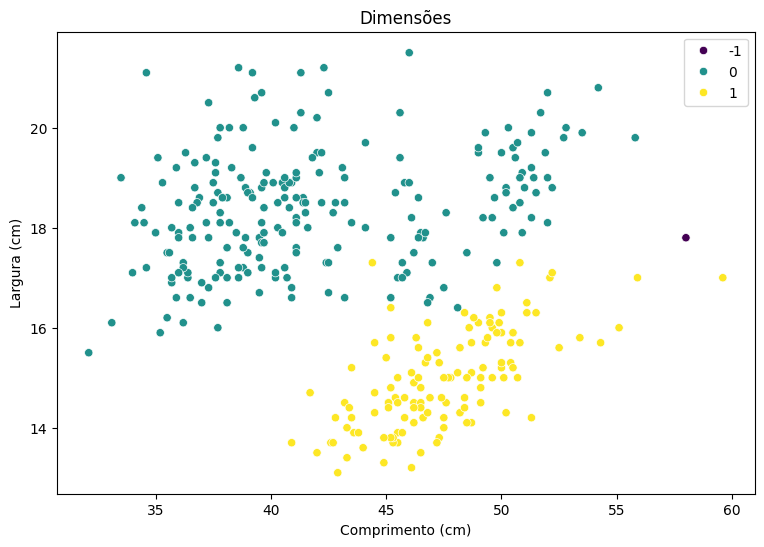

In [110]:
# Diagrama de dispersão entre comprimento e largura da pétala
# Ajustes da figura
# Tamanho do gráfico (polegadas): largura = 9, altura = 6
plt.figure(figsize = (9,6))

# Título e rótulos dos eixos
plt.title("Dimensões")
plt.xlabel("Comprimento (cm)")
plt.ylabel("Largura (cm)")

sns.scatterplot(data = df, x = 'culmen_length_mm', y = 'culmen_depth_mm',
                hue = clt_DB.labels_, palette = 'viridis')
plt.show()

### **6.4)** Número "ideal" de grupos: <u>dendrograma</u>

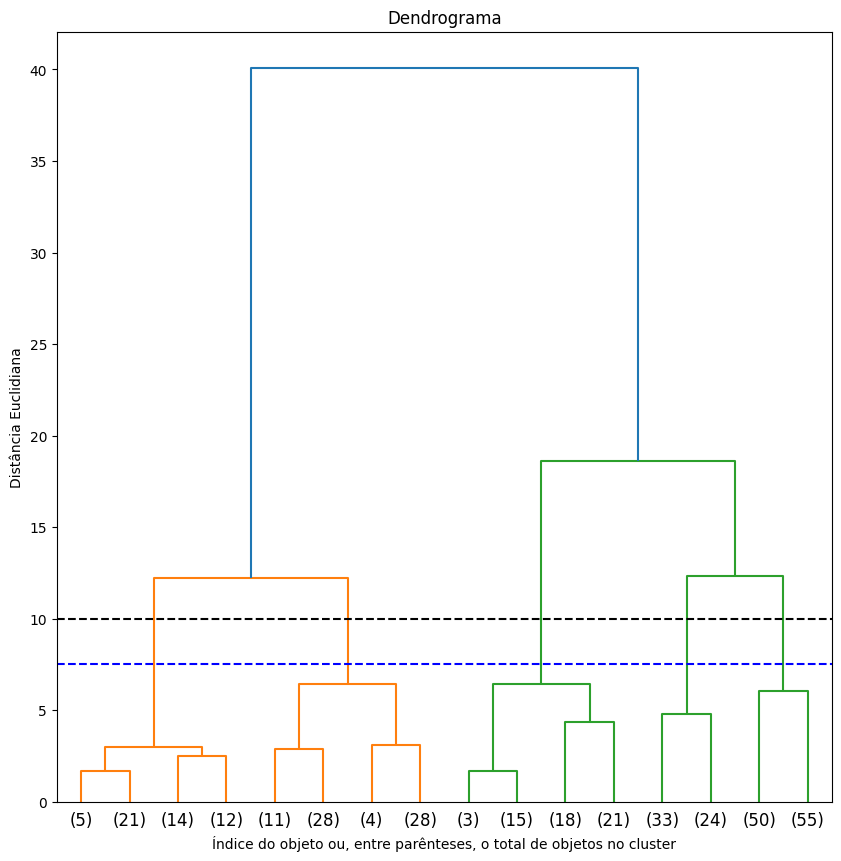

In [107]:
# Importação das bibliotecas necessárias
from scipy.cluster.hierarchy import dendrogram, linkage

# Criação e representação gráfica da estrutura em árvore, truncada no 3o nível
# O "p-ésimo" nível inclui todos os nós que estejam a "p" fusões/aglomerações
# da fusão/aglomeração final
plt.figure(figsize = (10,10))
dendro = dendrogram(linkage(X_Padr,method = 'ward'),truncate_mode = "level", p = 3)
plt.title("Dendrograma")
plt.xlabel("Índice do objeto ou, entre parênteses, o total de objetos no cluster")
plt.ylabel("Distância Euclidiana")
plt.axhline(y = 10,linestyle = '--',color = 'black')  # "Linha de corte" preta: 3 clusters
plt.axhline(y = 7.5,linestyle = '--',color = 'blue')  # "Linha de corte" azul: 4 clusters
plt.show()

### **4.5)** Agrupamento final

In [108]:
# Treinamento do HAC, com 3 clusters
# Criação de instância e treinamento do clusterizador
clt_AC = AgglomerativeClustering(n_clusters = 3)
clt_AC.fit(X_Padr)

AgglomerativeClustering(n_clusters=3)

### **6.6)** Gráficos finais

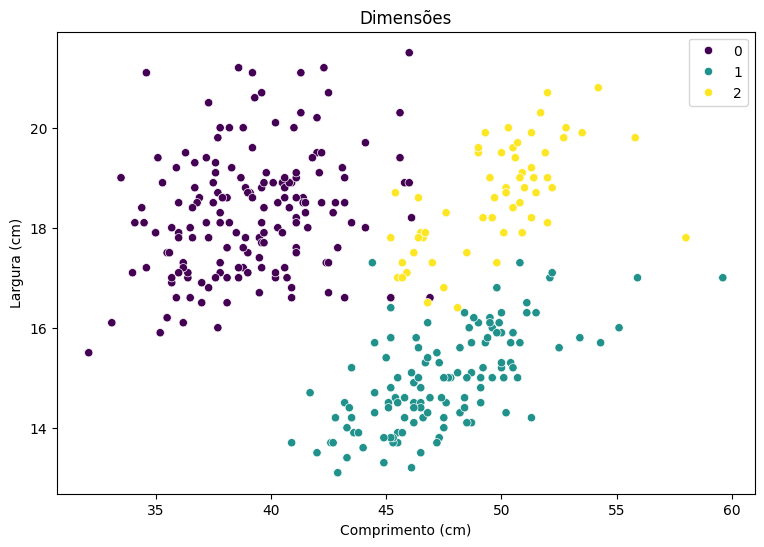

In [112]:
# Diagrama de dispersão entre comprimento e largura da pétala
# Ajustes da figura
# Tamanho do gráfico (polegadas): largura = 9, altura = 6
plt.figure(figsize = (9,6))

# Título e rótulos dos eixos
plt.title("Dimensões")
plt.xlabel("Comprimento (cm)")
plt.ylabel("Largura (cm)")

sns.scatterplot(data = df, x = 'culmen_length_mm', y = 'culmen_depth_mm',
                hue = clt_AC.labels_, palette = 'viridis')
plt.show()

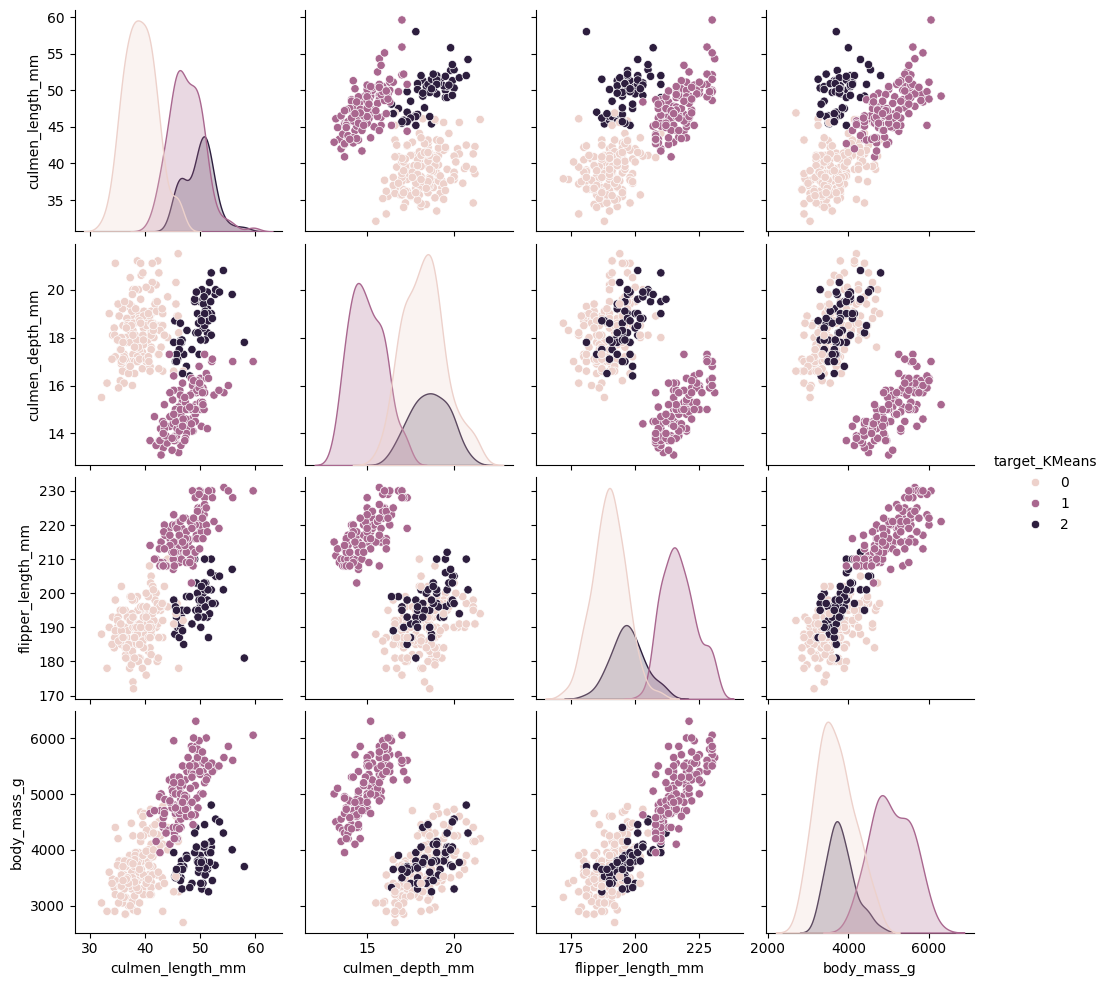

In [113]:
# Matriz de diagramas de dispersão, com separação de cor de acordo
# com a rotulação definida pelo clusterizador para o K = 3, como o método kneed nos mostrou

# Atribuição dos rótulos de cluster/cor ao DataFrame
df['target_KMeans'] = clt_AC.labels_

sns.pairplot(data = df.drop(columns = ['species', 'island', 'sex']),
             diag_kind = 'kde', hue = 'target_KMeans')
plt.show()

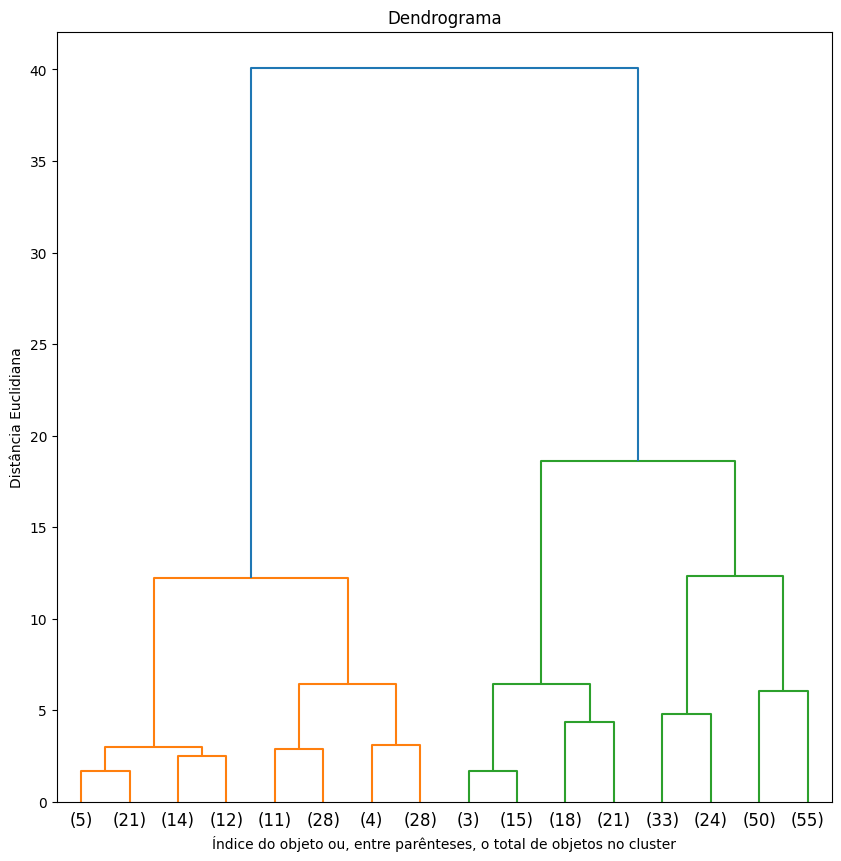

In [114]:
# Importação das bibliotecas necessárias
from scipy.cluster.hierarchy import dendrogram, linkage

# Criação e representação gráfica da estrutura em árvore, truncada no 3o nível
# O "p-ésimo" nível inclui todos os nós que estejam a "p" fusões/aglomerações
# da fusão/aglomeração final
plt.figure(figsize = (10,10))
dendro = dendrogram(linkage(X_Padr,method = 'ward'),truncate_mode = "level", p = 3)
plt.title("Dendrograma")
plt.xlabel("Índice do objeto ou, entre parênteses, o total de objetos no cluster")
plt.ylabel("Distância Euclidiana")
plt.show()

---
**Fim do terceiro trabalho**